<a href="https://colab.research.google.com/github/erdijova/Introduction-to-Machine-Learning-with-Python-A-Guide-for-Data-Scientists/blob/main/7_working_with_text_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [1]:
!pip install -q datasets nltk mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 9.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Patch mglearn.tools.heatmap for numpy/matplotlib compatibility
import mglearn.tools as _mt
def _patched_heatmap(values, xlabel, ylabel, xticklabels, yticklabels,
                     cmap=None, vmin=None, vmax=None, ax=None, fmt="%0.2f"):
    if ax is None:
        ax = plt.gca()
    values = np.array(values, dtype=np.float64)
    img = ax.pcolor(values, cmap=cmap, vmin=vmin, vmax=vmax)
    img.update_scalarmappable()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(len(xticklabels)) + .5)
    ax.set_yticks(np.arange(len(yticklabels)) + .5)
    ax.set_xticklabels(xticklabels)
    ax.set_yticklabels(yticklabels)
    ax.set_aspect(1)
    for p, color, value in zip(img.get_paths(), img.get_facecolors(),
                               values.ravel()):
        x, y = p.vertices[:-2, :].mean(0)
        c = 'k' if np.mean(color[:3]) > 0.5 else 'w'
        ax.text(x, y, fmt % float(value), color=c, ha="center", va="center")
    return img
_mt.heatmap = _patched_heatmap

## Loading the IMDb Dataset

We use the `datasets` library from Hugging Face to load the IMDb movie reviews dataset. This dataset contains 25,000 training reviews and 25,000 test reviews, each labeled as positive ($y = 1$) or negative ($y = 0$).

In [3]:
from datasets import load_dataset

# Load the IMDb dataset
imdb = load_dataset("imdb")

# Extract text and labels
text_train = imdb['train']['text']
y_train = np.array(imdb['train']['label'])

text_test = imdb['test']['text']
y_test = np.array(imdb['test']['label'])

print("type of text_train: {}".format(type(text_train)))
print("length of text_train: {}".format(len(text_train)))
print("text_train[1]:\n{}".format(text_train[1][:300]))

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

type of text_train: <class 'datasets.arrow_dataset.Column'>
length of text_train: 25000
text_train[1]:
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity


The dataset contains 25,000 text entries stored in an efficient column format, which behaves similarly to a list.

From a sample review, we can see that real-world text data is complex. It may include names, informal language, opinions, references, and even HTML tags like line breaks. These elements make the data rich but also noisy.

Before building a model, it is a good idea to clean the text by removing unnecessary formatting (such as HTML tags) to make the data more consistent and easier to process:

In [4]:
# Clean HTML tags
text_train = [doc.replace("<br />", " ") for doc in text_train]
text_test = [doc.replace("<br />", " ") for doc in text_test]

The dataset was collected such that the positive class and the negative class are balanced:

In [5]:
print("Samples per class (training): {}".format(np.bincount(y_train)))
print("Number of documents in test data: {}".format(len(text_test)))
print("Samples per class (test): {}".format(np.bincount(y_test)))

Samples per class (training): [12500 12500]
Number of documents in test data: 25000
Samples per class (test): [12500 12500]


The dataset is perfectly balanced, with an equal number of positive and negative reviews in both training and test sets. This makes it ideal for classification tasks.

Because of this balance:
- Accuracy becomes a reliable metric, since random guessing would only achieve 50%.
- There is no need for special techniques to handle class imbalance.

The goal is to predict whether a review is positive or negative based on its text. However, machine learning models cannot work directly with raw text, so we need to convert it into a numerical format.

## Representing Text as Bag of Words

A simple and effective method is the **bag-of-words** approach. This method ignores word order and focuses only on how often each word appears in a document.

The process involves three main steps:
1. Split text into individual words (tokens)
2. Build a vocabulary of all unique words
3. Represent each document by counting how often each word appears

This results in a numerical vector for each document, where each value corresponds to the frequency of a specific word.

Although this method ignores word order, it is often surprisingly effective for many text classification tasks.

### Applying Bag-of-Words

This approach can be implemented using `CountVectorizer`. Let's first apply it to a simple example:

In [6]:
bards_words = ["The fool doth think he is wise,",
               "but the wise man knows himself to be a fool"]

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()
vect.fit(bards_words)

CountVectorizer()

In [8]:
print("Vocabulary size: {}".format(len(vect.vocabulary_)))
print("Vocabulary content:\n {}".format(vect.vocabulary_))

Vocabulary size: 13
Vocabulary content:
 {'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


The vocabulary contains a set of unique words, each assigned to a specific index. These indices correspond to the columns in the feature matrix, where each column represents how often a word appears.

Several preprocessing steps are applied automatically:
- All text is converted to lowercase
- Punctuation is removed
- Very short words (such as single letters) are ignored

These defaults help clean and standardize the text for better modeling.

To convert the text into a numerical representation using this vocabulary, we use the `transform` method:

In [9]:
bag_of_words = vect.transform(bards_words)
print("bag_of_words: {}".format(repr(bag_of_words)))

bag_of_words: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>


The bag-of-words representation is stored in a **SciPy sparse matrix** that only stores the nonzero entries. The matrix has shape $2 \times 13$ (two documents, 13 vocabulary words), with only 16 nonzero entries out of $2 \times 13 = 26$ total. The **sparsity** is $1 - 16/26 \approx 38\%$ for this tiny example.

Why sparse storage? In real applications with vocabularies of 50,000+ words, a single review might use only a few hundred distinct words, so over 99% of entries are zero. For our IMDb dataset, the dense matrix would require:

$$25{,}000 \times 74{,}849 \times 8 \text{ bytes} \approx 14.8 \text{ GB}$$

The sparse representation stores only the $\sim$3.4 million nonzero entries, reducing memory by over 99%. To inspect the actual content, we convert to a dense array:

In [10]:
print("Dense representation of bag_of_words:\n{}".format(
    bag_of_words.toarray()))

Dense representation of bag_of_words:
[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


In this example, each document is represented as a vector of word counts. Since no word appears more than once in each sentence, the values are either 0 or 1.

Each row corresponds to a sentence, and each column represents a word from the vocabulary. A value of 1 means the word appears in the sentence, while 0 means it does not.

By comparing the vectors, we can see that some words appear in both sentences. These shared words make the documents appear similar in the feature space, even though their meanings are quite different.

This highlights a key limitation of the bag-of-words approach: it ignores word order and context, which can lead to misleading similarities.

### Bag-of-Words for Movie Reviews

Next, we apply the same bag-of-words representation to the IMDb movie review dataset:

In [11]:
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)
print("X_train:\n{}".format(repr(X_train)))

X_train:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3431196 stored elements and shape (25000, 74849)>


The shape of `X_train` is $25{,}000 \times 74{,}849$, meaning the vocabulary contains **74,849 unique tokens** across all 25,000 training reviews. With 3,431,196 stored elements out of a potential $25{,}000 \times 74{,}849 \approx 1.87$ billion entries, the matrix is **99.8% sparse**.

On average, each review uses about $3{,}431{,}196 / 25{,}000 \approx 137$ distinct tokens from the vocabulary of 74,849. A typical review uses less than 0.2% of the available vocabulary -- this extreme sparsity is characteristic of text data and is why sparse matrix storage is essential.

Let's look at the vocabulary in more detail:

In [12]:
feature_names = vect.get_feature_names_out()
print("Number of features: {}".format(len(feature_names)))
print("First 20 features:\n{}".format(feature_names[:20]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 2000th feature:\n{}".format(feature_names[::2000]))

Number of features: 74849
First 20 features:
['00' '000' '0000000000001' '00001' '00015' '000s' '001' '003830' '006'
 '007' '0079' '0080' '0083' '0093638' '00am' '00pm' '00s' '01' '01pm' '02']
Features 20010 to 20030:
['dratted' 'draub' 'draught' 'draughts' 'draughtswoman' 'draw' 'drawback'
 'drawbacks' 'drawer' 'drawers' 'drawing' 'drawings' 'drawl' 'drawled'
 'drawling' 'drawn' 'draws' 'draza' 'dre' 'drea']
Every 2000th feature:
['00' 'aesir' 'aquarian' 'barking' 'blustering' 'bête' 'chicanery'
 'condensing' 'cunning' 'detox' 'draper' 'enshrined' 'favorit' 'freezer'
 'goldman' 'hasan' 'huitieme' 'intelligible' 'kantrowitz' 'lawful' 'maars'
 'megalunged' 'mostey' 'norrland' 'padilla' 'pincher' 'promisingly'
 'receptionist' 'rivals' 'schnaas' 'shunning' 'sparse' 'subset'
 'temptations' 'treatises' 'unproven' 'walkman' 'xylophonist']


The dataset results in a very large number of features, showing how rich and diverse the vocabulary is.

From inspecting the vocabulary, we can observe:
- Many tokens are just numbers, which usually do not carry useful meaning (except special cases like well-known references).
- Different forms of the same word are treated as separate features, which can be inefficient and may lead to overfitting.
- The vocabulary covers a wide range of words, indicating good representation of the text data.

These observations show that while the bag-of-words approach is effective, it can still be improved by refining how text is processed.

Before making improvements, we first build a baseline model. For this type of high-dimensional text data, linear models such as `LogisticRegression` are often a strong starting point:

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(LogisticRegression(max_iter=5000), X_train, y_train, cv=5)
print("Mean cross-validation accuracy: {:.2f}".format(np.mean(scores)))

Mean cross-validation accuracy: 0.84


We achieve a mean cross-validation accuracy of around 84%, which is already a strong baseline considering we only used simple word counts as features.

In this model, each word contributes to the final prediction. Words associated with positive sentiment push the prediction toward positive, while negative words push it in the opposite direction. The final decision is based on the combined influence of all words in a review.

Logistic regression includes a parameter (`C`) that controls how much the model focuses on fitting the data versus keeping the model simple. Tuning this parameter can improve performance.

Next, we optimize this parameter using cross-validation:

In [14]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters: ", grid.best_params_)

Best cross-validation score: 0.87
Best parameters:  {'C': 0.01}


Tuning the parameter improved performance from 0.84 to 0.87, which is a noticeable gain.

The best result was achieved with a much smaller value than the default. This indicates that strong regularization is important for this type of data.

In text classification, the number of features (words) is very large compared to the number of samples. Without proper regularization, the model can easily overfit by assigning importance to irrelevant words.

Using stronger regularization helps the model focus only on the most informative words and ignore noise, leading to better generalization.

Next, we evaluate the model on the test set to see how well it performs on unseen data:

In [15]:
X_test = vect.transform(text_test)
print("Test set score: {:.2f}".format(grid.score(X_test, y_test)))

Test set score: 0.88


The model achieves 88% accuracy on the test set, which is slightly higher than the cross-validation score. This small difference is normal and suggests that the model generalizes well without overfitting.

This is an impressive result considering the simplicity of the approach. By only counting word occurrences and applying a regularized linear model, we already obtain strong performance.

This highlights an important idea in natural language processing: simple methods like bag-of-words combined with regularized linear models can be very effective and serve as strong baselines.

### Improving Feature Extraction with `min_df`

One way to improve the representation is by removing very rare words. Words that appear only once or a few times are often not useful and may introduce noise.

The `min_df` parameter allows us to keep only words that appear in a minimum number of documents, helping reduce the number of irrelevant features and improving generalization:

In [16]:
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)
print("X_train with min_df: {}".format(repr(X_train)))

X_train with min_df: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3354014 stored elements and shape (25000, 27271)>


In [17]:
feature_names = vect.get_feature_names_out()
print("First 50 features:\n{}".format(feature_names[:50]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 700th feature:\n{}".format(feature_names[::700]))

First 50 features:
['00' '000' '007' '00s' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10'
 '100' '1000' '100th' '101' '102' '103' '104' '105' '107' '108' '10s'
 '10th' '11' '110' '112' '116' '117' '11th' '12' '120' '12th' '13' '135'
 '13th' '14' '140' '14th' '15' '150' '15th' '16' '160' '1600' '16mm' '16s'
 '16th']
Features 20010 to 20030:
['repentance' 'repercussions' 'repertoire' 'repetition' 'repetitions'
 'repetitious' 'repetitive' 'rephrase' 'replace' 'replaced' 'replacement'
 'replaces' 'replacing' 'replay' 'replayable' 'replayed' 'replaying'
 'replays' 'replete' 'replica']
Every 700th feature:
['00' 'affections' 'appropriately' 'barbra' 'blurbs' 'butchered' 'cheese'
 'commitment' 'courts' 'deconstructed' 'disgraceful' 'dvds' 'eschews'
 'fell' 'freezer' 'goriest' 'hauser' 'hungary' 'insinuate' 'juggle'
 'leering' 'maelstrom' 'messiah' 'music' 'occasional' 'parking'
 'pleasantville' 'pronunciation' 'recipient' 'reviews' 'sas' 'shea'
 'sneers' 'steiger' 'swastika' 'thrusting' 't

After applying `min_df`, the vocabulary becomes cleaner and more meaningful. Rare and noisy tokens are mostly removed, while commonly used words remain.

Some numbers and specific terms still appear because they occur frequently enough in the dataset. We also still see multiple forms of the same word treated as separate features, which could be improved later with techniques like stemming.

Overall, the vocabulary now better represents meaningful language patterns, with fewer irrelevant tokens.

Next, we evaluate whether this cleaner feature set improves model performance:

In [18]:
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.87


The validation accuracy remains at 0.87 even after reducing the number of features. This shows that removing rare words did not hurt performance.

Although accuracy stays the same, there are important practical benefits:
- Training becomes faster due to fewer features
- Memory usage is reduced
- The model becomes easier to interpret

This confirms that many words in the original vocabulary were just noise and did not contribute to prediction.

## Stopwords

Another way to improve the feature set is by removing **stopwords**—very common words like “the”, “and”, or “is” that usually do not carry meaningful information.

There are two common approaches:
- Use a predefined list of stopwords for a language
- Automatically remove very frequent words based on how often they appear in the dataset

Scikit-learn provides a built-in list of stopwords that can be used directly:

In [19]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
print("Number of stop words: {}".format(len(ENGLISH_STOP_WORDS)))
print("Every 10th stopword:\n{}".format(list(ENGLISH_STOP_WORDS)[::10]))

Number of stop words: 318
Every 10th stopword:
['couldnt', 'over', 'throughout', 'from', 'keep', 'whence', 'above', 'after', 'hers', 'becomes', 'ten', 'out', 'below', 'along', 'nowhere', 'his', 'every', 'whither', 'was', 'least', 'had', 'within', 'nine', 'by', 'latterly', 'into', 'many', 'them', 'would', 'twenty', 'something', 'full']


The built-in list contains 318 common English words -- articles ("the", "a"), prepositions ("into", "from"), pronouns ("you", "my"), auxiliary verbs ("been", "had"), and similar function words. These words appear in nearly every document and therefore carry little **document-level discriminative power** in information retrieval.

However, there's a critical nuance for **sentiment analysis**: some "stopwords" like "not", "no", "but", "too" carry important sentiment information. The phrase "not good" has the opposite meaning of "good", and removing "not" would destroy this signal entirely. Let's see what happens:

In [20]:
# Specifying stop_words="english" uses the built-in list
vect = CountVectorizer(min_df=5, stop_words="english").fit(text_train)
X_train = vect.transform(text_train)
print("X_train with stop words:\n{}".format(repr(X_train)))

X_train with stop words:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2149958 stored elements and shape (25000, 26966)>


After removing stopwords, the number of features decreases only slightly. However, the total number of word occurrences drops significantly.

This shows that stopwords appear very frequently in the text, even though they do not carry much useful information. Removing them greatly reduces the amount of data the model needs to process.

The key question now is whether removing these frequent but uninformative words improves or harms the model’s performance:

In [21]:
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.86


After removing stopwords, performance slightly decreased from 0.87 to 0.86. This shows that some commonly removed words actually carry important meaning in sentiment analysis.

Words like “not”, “no”, and “but” can completely change the meaning of a sentence. Removing them may lead to incorrect interpretations, such as turning “not good” into “good”.

This highlights that stopword removal is not always beneficial, especially for tasks like sentiment classification.

## Using TF-IDF for Better Feature Representation

Instead of removing words, another approach is to adjust their importance using **TF-IDF**.

The idea behind TF-IDF:
- Words that appear frequently in a document are important for that document
- Words that appear in many documents are less informative overall

This method gives higher weight to words that are specific and meaningful, while reducing the influence of very common words.

After applying TF-IDF, the feature vectors are often normalized so that documents of different lengths can be compared fairly.

Since TF-IDF depends on the dataset, it should be applied within a pipeline to ensure proper handling during cross-validation:

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(TfidfVectorizer(min_df=5, norm=None),
                     LogisticRegression(max_iter=5000))
param_grid = {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10]}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.86


The TF-IDF pipeline achieves **0.86** cross-validation accuracy with `norm=None` (no L2 normalization), comparable to the raw word count approach. The fact that TF-IDF doesn't dramatically outperform raw counts reflects that logistic regression with $\ell_2$ regularization already handles feature scaling: it can learn to downweight common words through smaller coefficients.

Let's inspect which words TF-IDF found most important. Keep in mind that TF-IDF is a **purely unsupervised technique** -- "important" here means "distinctive for a particular document," not necessarily "predictive of sentiment":

In [23]:
vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]
# transform the training dataset
X_train = vectorizer.transform(text_train)
# find maximum value for each of the features over the dataset
max_value = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()
# get feature names
feature_names = np.array(vectorizer.get_feature_names_out())

print("Features with lowest tfidf:\n{}".format(
    feature_names[sorted_by_tfidf[:20]]))
print("\nFeatures with highest tfidf:\n{}".format(
    feature_names[sorted_by_tfidf[-20:]]))

Features with lowest tfidf:
['poignant' 'disagree' 'instantly' 'importantly' 'lacked' 'occurred'
 'currently' 'altogether' 'nearby' 'undoubtedly' 'directs' 'fond'
 'avoided' 'stinker' 'emphasis' 'commented' 'disappoint' 'realizing'
 'downhill' 'inane']

Features with highest tfidf:
['coop' 'homer' 'dillinger' 'hackenstein' 'gadget' 'macarthur' 'taker'
 'vargas' 'jesse' 'basket' 'dominick' 'the' 'victor' 'bridget' 'victoria'
 'khouri' 'zizek' 'rob' 'timon' 'titanic']


Words with **low TF-IDF scores** are typically common across many documents or appear only rarely. Because of this, they do not help distinguish one review from another.

In contrast, words with **high TF-IDF scores** are often very specific, such as names of movies, characters, or people. These words appear frequently in a small number of documents, making them stand out strongly in those cases.

However, these highly specific words are not always useful for general sentiment analysis, since they may relate more to particular topics rather than expressing positive or negative opinions.

To better understand this, we can also examine the words that appear most frequently across the entire dataset, as these tend to have the lowest importance:

In [24]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print("Features with lowest idf:\n{}".format(
    feature_names[sorted_by_idf[:100]]))

Features with lowest idf:
['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'have' 'one' 'be' 'film' 'are' 'you' 'all'
 'at' 'an' 'by' 'so' 'from' 'like' 'who' 'they' 'there' 'if' 'his' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'good' 'can' 'more' 'when'
 'time' 'up' 'very' 'even' 'only' 'no' 'would' 'my' 'see' 'really' 'story'
 'which' 'well' 'had' 'me' 'than' 'much' 'their' 'get' 'were' 'other'
 'been' 'do' 'most' 'don' 'her' 'also' 'into' 'first' 'made' 'how' 'great'
 'because' 'will' 'people' 'make' 'way' 'could' 'we' 'bad' 'after' 'any'
 'too' 'then' 'them' 'she' 'watch' 'think' 'acting' 'movies' 'seen' 'its'
 'him']


The most frequent words in the dataset are mostly common English words, along with domain-specific terms like “movie”, “film”, and “acting”.

Interestingly, important sentiment words such as “good”, “great”, and “bad” are also very frequent. Because TF-IDF downweights words that appear in many documents, these important words may be treated as less significant, even though they are highly useful for predicting sentiment.

This highlights a key limitation: TF-IDF focuses on distinguishing documents, not directly on predicting labels. As a result, it may undervalue words that are actually important for classification.

### Investigating Model Coefficients

To understand what the model has learned, we can examine the words with the strongest positive and negative influence based on their coefficients:

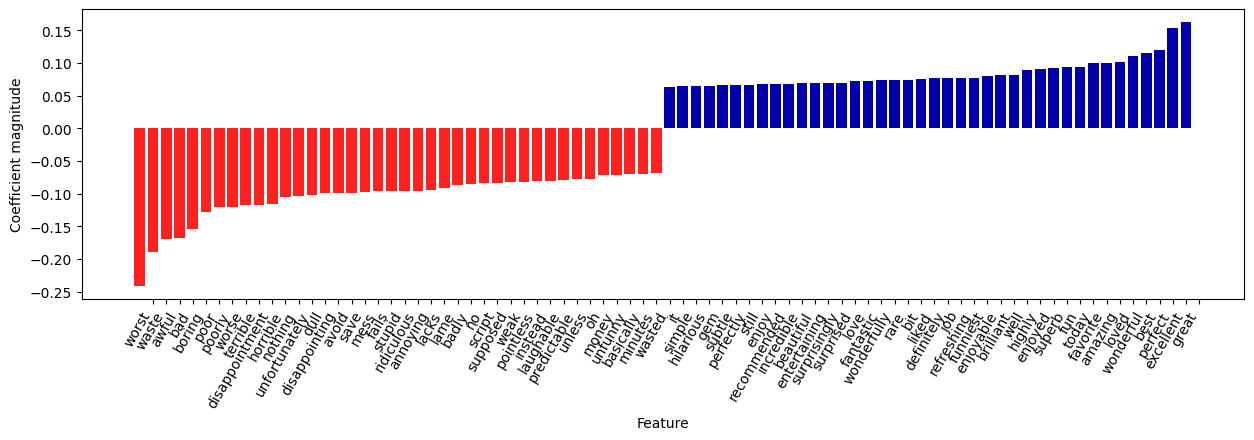

In [25]:
mglearn.tools.visualize_coefficients(
    grid.best_estimator_.named_steps["logisticregression"].coef_,
    feature_names, n_top_features=40)

The model’s coefficients show which words influence predictions the most.

- Words with strong negative weights are linked to negative reviews, such as “worst”, “awful”, and “disappointment”.
- Words with strong positive weights are linked to positive reviews, such as “excellent”, “wonderful”, and “superb”.

These results align well with human intuition, showing that the model has learned meaningful patterns from the data.

Some words are less clear on their own because their meaning depends on context. Since the model looks at individual words only, it cannot fully capture phrases or word order.

A key advantage of this approach is interpretability—we can directly see which words drive predictions, making the model easier to understand and trust.

## Using n-Grams for Better Context

One limitation of bag-of-words is that it ignores word order. This can cause sentences with opposite meanings to look identical.

To address this, we can use **n-grams**, which consider sequences of words instead of single words. For example:
- Unigrams: single words
- Bigrams: pairs of consecutive words
- Trigrams: sequences of three words

Using n-grams helps capture context and improves the model’s ability to understand phrases:

In [26]:
print("bards_words:\n{}".format(bards_words))

bards_words:
['The fool doth think he is wise,', 'but the wise man knows himself to be a fool']


These are our two toy Shakespeare-inspired sentences. With `ngram_range=(1, 1)` (the default), `CountVectorizer` creates one feature per single token -- identical to what we saw before:

In [27]:
cv = CountVectorizer(ngram_range=(1, 1)).fit(bards_words)
print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary:\n{}".format(cv.get_feature_names_out().tolist()))

Vocabulary size: 13
Vocabulary:
['be', 'but', 'doth', 'fool', 'he', 'himself', 'is', 'knows', 'man', 'the', 'think', 'to', 'wise']


With unigrams, we get the same 13 words. Each captures only a single word's presence: the model knows "fool", "wise", "the", and "man" all appeared, but it **cannot** distinguish "the fool" from "the wise man." To capture word pairs, we set `ngram_range` to $(2, 2)$:

In [28]:
cv = CountVectorizer(ngram_range=(2, 2)).fit(bards_words)
print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary:\n{}".format(cv.get_feature_names_out().tolist()))

Vocabulary size: 14
Vocabulary:
['be fool', 'but the', 'doth think', 'fool doth', 'he is', 'himself to', 'is wise', 'knows himself', 'man knows', 'the fool', 'the wise', 'think he', 'to be', 'wise man']


With bigrams only, the vocabulary grows to 14 two-word features. Notice something powerful: there is **no common bigram** between the two phrases. "the fool" only appears in the first string, "the wise" only in the second. Compare this to unigrams where "the", "fool", and "wise" were all shared -- bigrams are far more discriminative.

The bigrams preserve local word order: "the fool" and "fool the" would be separate features. The dense representation confirms the complete separation:

In [29]:
print("Transformed data (dense):\n{}".format(cv.transform(bards_words).toarray()))

Transformed data (dense):
[[0 0 1 1 1 0 1 0 0 1 0 1 0 0]
 [1 1 0 0 0 1 0 1 1 0 1 0 1 1]]


The two rows share **zero common features** -- the cosine similarity is exactly zero. In unigram space, the documents shared 3 features; in bigram space, they are completely orthogonal. This illustrates how n-grams provide much sharper discrimination, at the cost of a larger vocabulary.

Here is what using unigrams, bigrams, and trigrams together looks like:

In [30]:
cv = CountVectorizer(ngram_range=(1, 3)).fit(bards_words)
print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary:\n{}".format(cv.get_feature_names_out().tolist()))

Vocabulary size: 39
Vocabulary:
['be', 'be fool', 'but', 'but the', 'but the wise', 'doth', 'doth think', 'doth think he', 'fool', 'fool doth', 'fool doth think', 'he', 'he is', 'he is wise', 'himself', 'himself to', 'himself to be', 'is', 'is wise', 'knows', 'knows himself', 'knows himself to', 'man', 'man knows', 'man knows himself', 'the', 'the fool', 'the fool doth', 'the wise', 'the wise man', 'think', 'think he', 'think he is', 'to', 'to be', 'to be fool', 'wise', 'wise man', 'wise man knows']


When using n-grams, the number of features grows rapidly. Even with a small example, combining single words with pairs and triples already increases the vocabulary significantly.

In larger datasets, this growth becomes much more noticeable, potentially leading to hundreds of thousands of features.

In practice:
- Using single words (unigrams) is essential, as they capture most of the meaning.
- Adding word pairs (bigrams) helps capture important phrases like “not good” or “very bad”.
- Adding longer sequences can provide more context but may also increase the risk of overfitting.

Because of this trade-off, it is common to use unigrams together with bigrams, and sometimes trigrams if needed.

Next, we apply TF-IDF combined with n-grams to the IMDb dataset:

In [ ]:
pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression(max_iter=5000))
# running the grid search takes a long time because of the
# relatively large grid and the inclusion of trigrams
param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100],
              "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)]}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters:\n{}".format(grid.best_params_))

In [34]:
# extract scores from grid_search
scores = grid.cv_results_['mean_test_score'].reshape(-1, 3).T
# visualize heat map
heatmap = mglearn.tools.heatmap(
    scores, xlabel="C", ylabel="ngram_range", cmap="viridis", fmt="%.3f",
    xticklabels=param_grid['logisticregression__C'],
    yticklabels=param_grid['tfidfvectorizer__ngram_range'])
plt.colorbar(heatmap)

AttributeError: 'GridSearchCV' object has no attribute 'cv_results_'

In [35]:
# extract feature names and coefficients
vect = grid.best_estimator_.named_steps['tfidfvectorizer']
feature_names = np.array(vect.get_feature_names_out())
coef = grid.best_estimator_.named_steps['logisticregression'].coef_
mglearn.tools.visualize_coefficients(coef, feature_names, n_top_features=40)

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

Using n-grams allows the model to capture context that single words cannot.

For example:
- Phrases like “not worth” are clearly negative
- Phrases like “well worth” or “definitely worth” are clearly positive

The word “worth” alone is ambiguous, but n-grams help resolve its meaning by considering surrounding words.

Other useful patterns also appear:
- Negative phrases like “waste of” or “the worst”
- Positive constructions like “one of” (often part of “one of the best”)

These multi-word features act as meaningful units, improving the model’s understanding of sentiment.

Next, we can focus specifically on trigram features to see even richer contextual patterns:

In [ ]:
# find 3-gram features
mask = np.array([len(feature.split(" ")) for feature in feature_names]) == 3
# visualize only 3-gram features
mglearn.tools.visualize_coefficients(coef.ravel()[mask],
    feature_names[mask], n_top_features=40)

Trigram features can capture meaningful phrases that single words cannot. Expressions like “waste of time” or “one of the best” clearly convey sentiment, even though their individual words may not be very informative.

However, in practice:
- Unigrams provide the strongest overall signal
- Bigrams add significant contextual improvement
- Trigrams offer smaller, fine-grained refinements

This is why adding bigrams usually improves performance more than adding trigrams.

## Advanced Tokenization, Stemming, and Lemmatization

The default text processing methods are quite simple, and there are ways to improve them.

One issue is that different forms of the same word are treated as separate features, which can increase noise and overfitting.

To address this, we can normalize words:

- **Stemming** reduces words to a base form by removing suffixes. It is fast but may produce non-standard words.
- **Lemmatization** converts words to their proper base form using vocabulary and grammar rules. It is more accurate but slower.

These techniques help reduce the number of features and improve generalization.

Next, we compare an example of stemming:

In [ ]:
import nltk

# instantiate nltk's Porter stemmer
stemmer = nltk.stem.PorterStemmer()

# define function to compare stemming behavior
def show_stemming(doc):
    words = doc.split()
    print("Original: ", words)
    print("Stemmed:  ", [stemmer.stem(w.lower()) for w in words])

show_stemming("Our meeting today was worse than yesterday")
print()
show_stemming("I am scared of meeting the clients tomorrow")

Stemming helps reduce different word forms into a single representation, which can simplify the model and reduce noise.

It works well for merging similar words (like “meeting” and “meet”), but it can also produce unnatural word forms and cannot understand context. For example, it treats the same word the same way even if it has different meanings in different sentences.

Lemmatization is more accurate because it considers grammar and produces real words, but it is slower to compute.

Both techniques reduce the number of unique words and act as a form of regularization. They are especially helpful for smaller datasets, while their impact on large datasets is usually modest.

## Topic Modeling and Document Clustering

Beyond classification, we can also analyze text without labels using **topic modeling**.

### Latent Dirichlet Allocation (LDA)

LDA is a method that discovers hidden topics in a collection of documents. It assumes:
- Each document is made up of a mix of topics
- Each topic is defined by a group of related words

In simple terms, LDA identifies patterns of word usage and groups them into meaningful themes.

Before applying LDA, it is helpful to remove very common words and limit the vocabulary size to focus on more informative terms:

In [ ]:
vect = CountVectorizer(max_features=10000, max_df=.15)
X = vect.fit_transform(text_train)

We will learn a topic model with 10 topics:

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=10, learning_method="batch",
                                max_iter=25, random_state=0)
# We build the model and transform the data in one step
document_topics = lda.fit_transform(X)

`LatentDirichletAllocation` has a `components_` attribute that stores how important each word is for each topic. The size is $(K, p)$ where $K$ is the number of topics and $p$ is the vocabulary size:

In [ ]:
print("lda.components_.shape: {}".format(lda.components_.shape))

The `components_` matrix has shape $(10, 10{,}000)$: **10 rows** (one per topic) and **10,000 columns** (one per vocabulary word). Entry $\beta_{k,j}$ represents how important word $j$ is in topic $k$. Larger values mean the word is more characteristic of that topic. Each row can be thought of as a "word recipe" for generating documents about that topic.

To interpret the topics, we look at the highest-weight words in each:

In [ ]:
# For each topic (a row in the components_), sort the features (ascending)
# Invert rows with [:, ::-1] to make sorting descending
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
# Get the feature names from the vectorizer
feature_names = np.array(vect.get_feature_names_out())

In [ ]:
# Print out the 10 topics:
mglearn.tools.print_topics(topics=range(10), feature_names=feature_names,
                           sorting=sorting, topics_per_chunk=5, n_words=10)

By looking at the most important words in each topic, we can interpret what each topic represents:

- **Topic 0**: Focuses on family-related stories and relationships.
- **Topic 1**: Relates to musicals, performances, and acting.
- **Topic 2**: Represents comedy films, emphasizing humor and actors.
- **Topic 3**: Covers war and political themes.
- **Topic 4**: Captures negative sentiment, with words expressing dissatisfaction.

This shows that topic modeling can uncover both **genres** (like comedy or war) and **sentiment patterns** (like negative language).

With only a small number of topics, each one is quite broad. Increasing the number of topics allows for more detailed and specific groupings.

Next, we expand the model to use more topics for a finer analysis:

In [ ]:
lda100 = LatentDirichletAllocation(n_components=100, learning_method="batch",
                                   max_iter=25, random_state=0)
document_topics100 = lda100.fit_transform(X)

With 100 topics, we expect narrower, more interpretable themes. Let's examine a curated selection of interesting topics:

In [ ]:
topics = np.array([7, 16, 24, 25, 28, 36, 37, 45, 51, 53, 54, 63, 89, 97])
sorting = np.argsort(lda100.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names_out())
mglearn.tools.print_topics(topics=topics, feature_names=feature_names,
                           sorting=sorting, topics_per_chunk=7, n_words=20)

With 100 topics, the specialization is dramatically better. Each topic now represents a narrow, interpretable theme:

**Topic 7** (green, jim, bruce, world, heston): **Action/adventure** -- possibly Jim Carrey or Bruce Willis movies, Charlton Heston epics.

**Topic 16** (ring, team, ball, angle, player, match): **Sports movies** -- films about athletics, teams, and competition.

**Topic 24** (church, faith, victor, priest, religion): **Religious/spiritual themes** in films.

**Topic 25** (footage, werewolf, beast, stock, creature): **Horror/monster movies** -- creature features, found footage, supernatural horror.

**Topic 28** (wife, husband, family, woman, affair): **Domestic/relationship dramas** -- stories about marriages, affairs, and family conflict.

**Topic 36** (gay, subject, between, social, human): Movies dealing with **social themes, LGBTQ+ topics**, and human relationships.

**Topic 37** (lady, romantic, grace, ship): **Romance** movies -- love stories and period pieces.

**Topic 45** (song, songs, sing, musical, band, rock, dance): **Music-centered movies** -- musicals, musician biopics, concert films.

**Topic 54** (worst, awful, terrible, horrible, waste, boring): Pure **negative sentiment** -- the universal language of bad reviews, genre-independent.

**Topic 63** (funny, comedy, hilarious, laugh, jokes, humor): **Positive comedy reviews** -- the language of laughing and enjoying humor.

To verify our interpretations, we should check which actual reviews are most associated with each topic. Let's look at Topic 45 (music):

In [ ]:
# sort by weight of "music" topic 45
music = np.argsort(document_topics100[:, 45])[::-1]
# print the five documents where the topic is most important
for i in music[:5]:
    # show first two sentences
    print(".".join(text_train[i].split(".")[:2]) + ".\n")

The reviews most strongly linked to this topic clearly involve artistic or music-related elements. However, the topic is not limited to movies about music—it also includes films where reviews naturally discuss performance, emotion, and artistic expression.

This shows that topics capture broader patterns in language, not just strict categories. A single topic can represent a mix of related ideas based on how people describe movies.

This is why it is important to check real examples:  
- The top words suggest a possible interpretation  
- The actual documents confirm or refine that interpretation  

Next, we analyze how important each topic is across the entire dataset by looking at how frequently they appear:

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
topic_names = ["{:>2} ".format(i) + " ".join(words)
               for i, words in enumerate(feature_names[sorting[:, :2]])]
# two column bar chart:
for col in [0, 1]:
    start = col * 50
    end = (col + 1) * 50
    ax[col].barh(np.arange(50), np.sum(document_topics100, axis=0)[start:end])
    ax[col].set_yticks(np.arange(50))
    ax[col].set_yticklabels(topic_names[start:end], ha="left", va="top")
    ax[col].invert_yaxis()
    ax[col].set_xlim(0, 2000)
    yax = ax[col].get_yaxis()
    yax.set_tick_params(pad=130)
plt.tight_layout()

The topic distribution shows how much each topic contributes across all reviews.

We can observe:
- **Dominant topics** are either general sentiment (positive/negative language) or broad genres like drama and comedy, since these appear in many reviews.
- **Specialized topics** represent niche themes or specific subjects, appearing less often but strongly within certain reviews.

This reveals an important structure in the data:
- One dimension captures **what the movie is about** (genre)
- Another captures **how people feel about it** (sentiment)

Most reviews combine both aspects, mixing content description with opinions.

Topic modeling provides a compact representation of documents, reducing thousands of features into a smaller set of meaningful topics. This can be useful for further analysis or as input to other models.

However, topic models can vary depending on randomness, so results should always be validated by inspecting actual documents.

## Summary and Outlook

In this chapter, we explored key techniques for processing text in machine learning:

- **Bag-of-words**: represents text using word counts; simple but effective
- **TF-IDF**: adjusts word importance based on how unique they are
- **N-grams**: capture short phrases and improve context understanding
- **Stemming and lemmatization**: reduce word variations to simplify features
- **Topic modeling (LDA)**: uncovers hidden themes in text data

The main takeaway is that how we represent text has a huge impact on model performance. Carefully choosing and analyzing features is essential for building effective NLP systems.